# ATF DR RF-Track correction validation

Reference SAD daihon: `operation/daihon/atfdr-design-20111111b.sad`.

Each test follows: inject error → build response → solve SVD correction → apply → compare RMS.

## Scope

Use the `rftrack-env` kernel. This is a transverse-only model: RF acceleration and synchrotron radiation are not included.

## Twiss tables

`ATF_DR_twiss_file.tws` is a legacy MAD-X table with all lattice elements and a full column set. `ATF_DR_20111111b_RFTrack_twiss.tfs` is the importer-ready RF-Track DR lattice generated from `atfdr-design-20111111b.sad`. This Notebook loads it directly with `rft.Lattice(str(DR_TWISS_FILE))`. `ATF2_EXT_FF_v5.2.twiss` is an independent extraction-line table and is not a DR optics source.

In [1]:
from pathlib import Path
import sys
import time

from IPython import get_ipython
ipython = get_ipython()
if ipython is not None:
    ipython.run_line_magic("matplotlib", "inline")

import matplotlib.pyplot as plt
import numpy as np
import RF_Track as rft

# Locate the flight-simulator repository from the Jupyter working directory.
REPOSITORY_ROOT = Path.cwd().resolve()
while not (REPOSITORY_ROOT / "Interfaces").is_dir():
    if REPOSITORY_ROOT.parent == REPOSITORY_ROOT:
        raise RuntimeError("Could not find the flight-simulator repository root.")
    REPOSITORY_ROOT = REPOSITORY_ROOT.parent
sys.path.insert(0, str(REPOSITORY_ROOT))

# This is the exact file used to construct every RF-Track DR lattice below.
DR_TWISS_FILE = (
    REPOSITORY_ROOT
    / "Interfaces"
    / "ATF2"
    / "DR_ATF2"
    / "ATF_DR_20111111b_RFTrack_twiss.tfs"
)
REFERENCE_SAD_FILE = "operation/daihon/atfdr-design-20111111b.sad"
assert DR_TWISS_FILE.is_file(), DR_TWISS_FILE

from Interfaces.ATF2.DR_ATF2.ATF_DR_RFTrack_lattice import NOMINAL_MOMENTUM_MEV_C
from Interfaces.ATF2.DR_ATF2.ATF_DR_RFTrack_correction import ATFDRRingCorrection


def read_tfs_table(file_path):
    # Read the TFS data rows into a NumPy structured array.
    lines = file_path.read_text(encoding="utf-8").splitlines()
    header_index = next(i for i, line in enumerate(lines) if line.startswith("* "))
    column_names = lines[header_index].split()[1:]
    data_lines = [line for line in lines[header_index + 2:] if line.strip()]
    table = np.atleast_1d(
        np.genfromtxt(data_lines, names=column_names, dtype=None, encoding="utf-8")
    )
    for field in ("NAME", "KEYWORD"):
        table[field] = np.char.strip(table[field], '"')
    return table


plt.rcParams.update({"figure.dpi": 120, "axes.grid": True, "grid.alpha": 0.25})
print(f"repository root: {REPOSITORY_ROOT}")
print(f"RF-Track lattice file: {DR_TWISS_FILE}")


RF-Track, version 2.6.3

Copyright (C) 2016-2026 CERN, Geneva, Switzerland. All rights reserved.

Author and contact:
 Andrea Latina <andrea.latina@cern.ch>
 BE-ABP Group
 CERN
 CH-1211 GENEVA 23
 SWITZERLAND

This software is distributed under a CERN proprietary software
license in the hope that it will be useful, but WITHOUT ANY WARRANTY;
not even for MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.

See the COPYRIGHT and LICENSE files at the top-level directory of
the RF-Track download area: https://gitlab.cern.ch/rf-track

RF-Track was compiled with GSL-2.5 and fftw-3.3.5-sse2-avx

repository root: /home/motokisato/Projects/flight-simulator
RF-Track lattice file: /home/motokisato/Projects/flight-simulator/Interfaces/ATF2/DR_ATF2/ATF_DR_20111111b_RFTrack_twiss.tfs


[RF-Track] Could not check for updates.


## 1. Build lattice and track one turn

In [2]:
# Load the lattice directly from the importer-ready DR TFS file.
lattice_nominal = rft.Lattice(str(DR_TWISS_FILE))

print("reference SAD daihon:", REFERENCE_SAD_FILE)
print(f"circumference: {lattice_nominal.get_length():.9f} m")
print(
    "devices: "
    f"BPM={len(lattice_nominal.get_bpms())}, "
    f"quadrupole={len(lattice_nominal.get_quadrupoles())}, "
    f"ZH/ZV={len(lattice_nominal.get_correctors())} total"
)
print("RF elements:", len(lattice_nominal.get_rf_elements()), "(transverse-only model)")

# Track one on-momentum particle through the same TFS-loaded lattice.
phase_space = np.array([0.0, 0.0, 0.0, 0.0, 0.0, NOMINAL_MOMENTUM_MEV_C])
one_particle = rft.Bunch6d(rft.electronmass, 0.0, -1.0, phase_space)
tracked = lattice_nominal.track(one_particle)
final_momentum = tracked.get_phase_space()[0, 5]
print(f"one-turn particle count: {tracked.size()}")
print(f"p before/after: {NOMINAL_MOMENTUM_MEV_C:.7f} / {final_momentum:.7f} MeV/c")
assert tracked.size() == 1
assert np.isclose(final_momentum, NOMINAL_MOMENTUM_MEV_C, atol=1e-8)

reference SAD daihon: operation/daihon/atfdr-design-20111111b.sad
circumference: 138.559539412 m
devices: BPM=98, quadrupole=100, ZH/ZV=101 total
RF elements: 0 (transverse-only model)
one-turn particle count: 1
p before/after: 1299.9999000 / 1299.9999000 MeV/c


## 2. Nominal periodic orbit, dispersion, and Twiss

The nominal horizontal dispersion and the RF-Track-generated BPM Twiss table are loaded as references.

periodic fixed-point residual: 0.000e+00
nominal COD RMS: x=0.000e+00 mm, y=0.000e+00 mm
TFS rows: 1193 elements; 98 BPMs


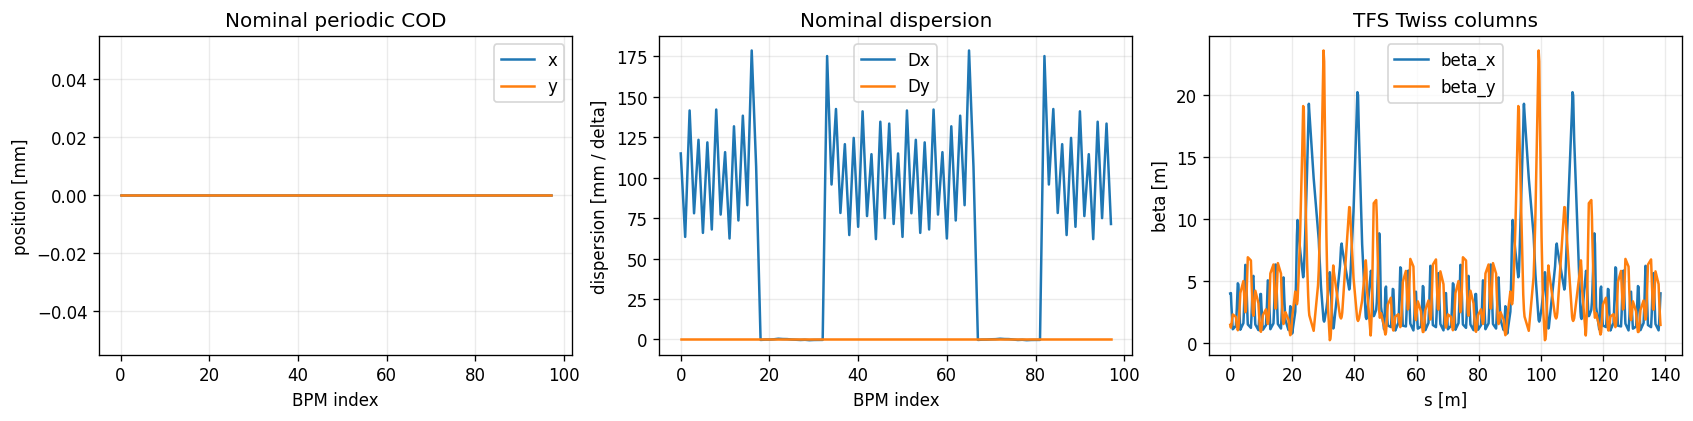

In [3]:
# Measure the nominal periodic orbit and dispersion in the TFS-loaded lattice.
nominal_correction = ATFDRRingCorrection(lattice_nominal)
nominal_orbit = nominal_correction.find_closed_orbit()
nominal_dispersion = nominal_correction.measure_dispersion(relative_momentum_step=1e-3)

# Read the same TFS file to display its optics columns.
twiss_table = read_tfs_table(DR_TWISS_FILE)
twiss_bpm = twiss_table[twiss_table["KEYWORD"] == "MONITOR"]

bpm_index = np.arange(len(nominal_orbit.bpm_names))
assert tuple(twiss_bpm["NAME"]) == nominal_orbit.bpm_names
assert np.allclose(twiss_bpm["DX"], nominal_dispersion.x, atol=1e-6)
assert np.allclose(twiss_bpm["DY"], nominal_dispersion.y, atol=1e-6)

print(f"periodic fixed-point residual: {nominal_orbit.residual_norm:.3e}")
print(f"nominal COD RMS: x={np.sqrt(np.mean(nominal_orbit.x**2)):.3e} mm, "
      f"y={np.sqrt(np.mean(nominal_orbit.y**2)):.3e} mm")
print(f"TFS rows: {len(twiss_table)} elements; {len(twiss_bpm)} BPMs")

fig, axes = plt.subplots(1, 3, figsize=(14, 3.4), constrained_layout=True)
axes[0].plot(bpm_index, nominal_orbit.x, label="x")
axes[0].plot(bpm_index, nominal_orbit.y, label="y")
axes[0].set(title="Nominal periodic COD", xlabel="BPM index", ylabel="position [mm]")
axes[0].legend()
axes[1].plot(bpm_index, nominal_dispersion.x, label="Dx")
axes[1].plot(bpm_index, nominal_dispersion.y, label="Dy")
axes[1].set(title="Nominal dispersion", xlabel="BPM index", ylabel="dispersion [mm / delta]")
axes[1].legend()
axes[2].plot(twiss_table["S"], twiss_table["BETX"], label="beta_x")
axes[2].plot(twiss_table["S"], twiss_table["BETY"], label="beta_y")
axes[2].set(title="TFS Twiss columns", xlabel="s [m]", ylabel="beta [m]")
axes[2].legend()
plt.show()

## 3. COD correction

Inject a horizontal or vertical steerer kick, then correct the periodic orbit with selected ZH or ZV steerers.

x-plane: RMS 1.869e-03 -> 8.997e-05 mm, selected=('ZH101R', 'ZH4R', 'ZH2R', 'ZH3R', 'ZH10R', 'ZH5R'), rank=6
y-plane: RMS 4.090e-04 -> 4.320e-05 mm, selected=('ZV5R', 'ZV6R', 'ZV2R', 'ZV3R', 'ZV4R', 'ZV12R'), rank=6


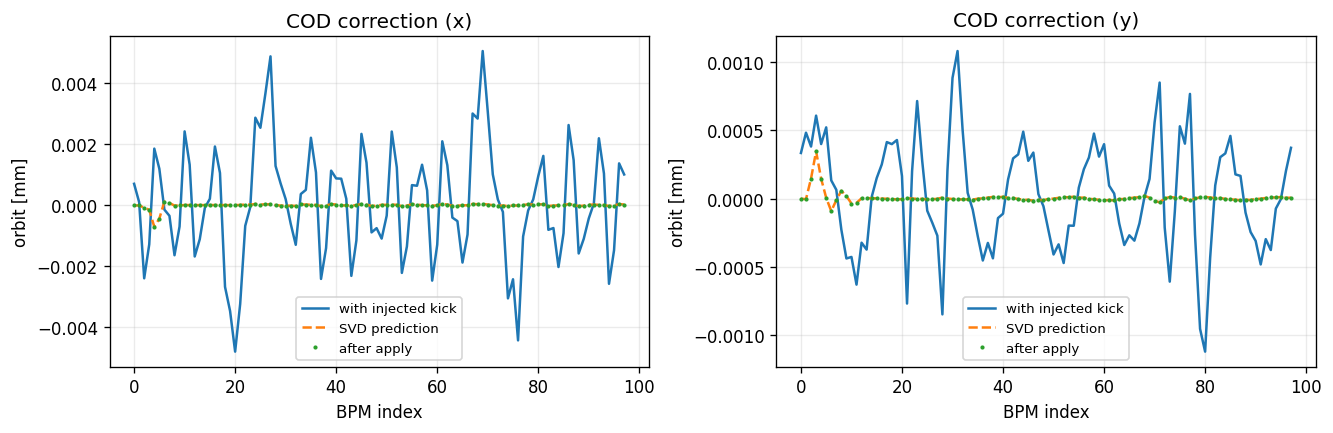

In [4]:
def rms(values):
    return float(np.sqrt(np.mean(np.asarray(values) ** 2)))


def run_cod_case(plane, error_corrector, strength_index):
    lattice = rft.Lattice(str(DR_TWISS_FILE))
    correction = ATFDRRingCorrection(lattice)

    injected_strength = np.zeros(2)
    injected_strength[strength_index] = 1e-3
    lattice[error_corrector].set_strength(*injected_strength)

    available = correction.get_corrector_names(plane)
    response = correction.compute_orbit_response(
        plane,
        corrector_names=available[1:13],
        perturbation=1e-5,
    )
    suggestion = correction.propose_orbit_correction(
        response,
        max_correctors=6,
        rcond=1e-4,
    )
    corrected = correction.apply_orbit_correction(suggestion)
    measured_after = corrected.x if plane == "x" else corrected.y

    assert len(suggestion.selected_correctors) <= 6
    assert np.isclose(rms(measured_after), suggestion.rms_predicted,
                      atol=max(1e-8, 0.01 * suggestion.rms_predicted))
    return {
        "plane": plane,
        "suggestion": suggestion,
        "rms_before": suggestion.rms_before,
        "rms_after": rms(measured_after),
        "measured_after": measured_after,
    }


cod_results = {
    "x": run_cod_case("x", "ZH1R", 0),
    "y": run_cod_case("y", "ZV1R", 1),
}

for plane, result in cod_results.items():
    s = result["suggestion"]
    print(
        f"{plane}-plane: RMS {result['rms_before']:.3e} -> {result['rms_after']:.3e} mm, "
        f"selected={s.selected_correctors}, rank={s.rank}"
    )

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5), sharex=True, constrained_layout=True)
for axis, plane in zip(axes, ("x", "y")):
    result = cod_results[plane]
    suggestion = result["suggestion"]
    axis.plot(bpm_index, suggestion.measured_orbit, label="with injected kick")
    axis.plot(bpm_index, suggestion.predicted_orbit, "--", label="SVD prediction")
    axis.plot(bpm_index, result["measured_after"], ".", ms=3, label="after apply")
    axis.set(title=f"COD correction ({plane})", xlabel="BPM index", ylabel="orbit [mm]")
    axis.legend(fontsize=8)
plt.show()

assert cod_results["x"]["rms_after"] < 0.10 * cod_results["x"]["rms_before"]
assert cod_results["y"]["rms_after"] < 0.20 * cod_results["y"]["rms_before"]

## 4. Dispersion correction

Inject a quadrupole K1 error. Correct horizontal dispersion and COD together with ZH steerers.

Injected QM10R.1 K1 error: 4.956427 -> 5.005991 1/m^2


Dx target error RMS: 2.613e+00 -> 7.533e-03 mm/delta
x COD RMS: 0.000e+00 -> 8.808e-05 mm; selected=('ZH3R', 'ZH1R', 'ZH2R')


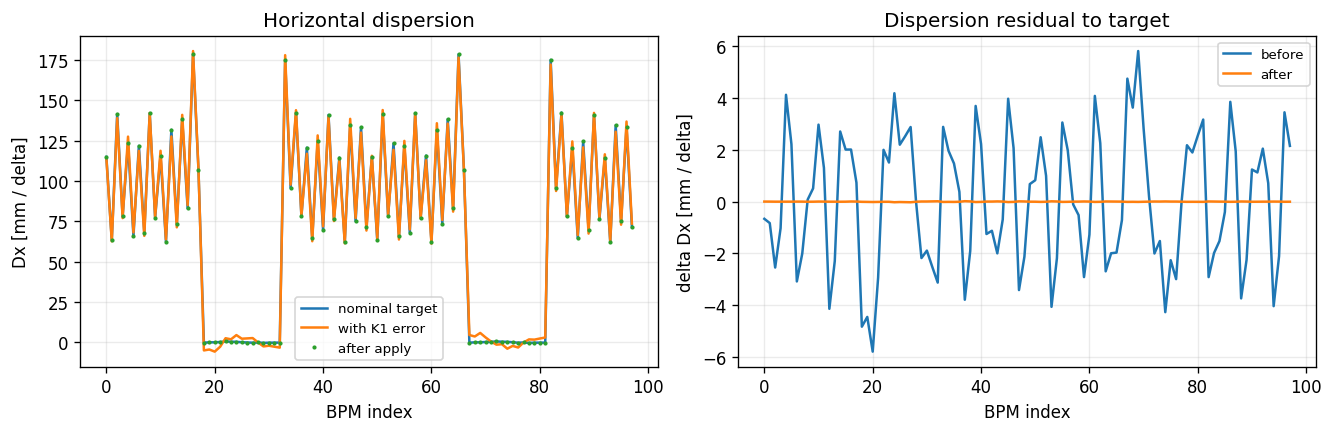

In [5]:
lattice_dispersion = rft.Lattice(str(DR_TWISS_FILE))
dispersion_correction = ATFDRRingCorrection(lattice_dispersion)
target_dispersion = dispersion_correction.measure_dispersion(relative_momentum_step=1e-3)

quadrupole = lattice_dispersion["QM10R.1"]
p_over_q = -NOMINAL_MOMENTUM_MEV_C
nominal_k1 = quadrupole.get_K1(p_over_q)
quadrupole.set_K1(p_over_q, nominal_k1 * 1.01)
print(f"Injected QM10R.1 K1 error: {nominal_k1:.7g} -> {nominal_k1 * 1.01:.7g} 1/m^2")

dispersion_response = dispersion_correction.compute_dispersion_response(
    "x",
    corrector_names=dispersion_correction.get_corrector_names("x")[:4],
    relative_momentum_step=1e-3,
    perturbation=1e-5,
)
dispersion_suggestion = dispersion_correction.propose_dispersion_correction(
    dispersion_response,
    target_dispersion=target_dispersion.x,
    dispersion_weight=0.05,
    orbit_weight=1.0,
    max_correctors=4,
    rcond=1e-4,
)
orbit_after_dispersion, dispersion_after = dispersion_correction.apply_dispersion_correction(
    dispersion_suggestion
)
dispersion_error_after = rms(dispersion_after.x - target_dispersion.x)
orbit_error_after = rms(orbit_after_dispersion.x)

print(
    f"Dx target error RMS: {dispersion_suggestion.dispersion_rms_before:.3e} -> "
    f"{dispersion_error_after:.3e} mm/delta"
)
print(
    f"x COD RMS: {dispersion_suggestion.orbit_rms_before:.3e} -> "
    f"{orbit_error_after:.3e} mm; selected={dispersion_suggestion.selected_correctors}"
)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5), sharex=True, constrained_layout=True)
axes[0].plot(bpm_index, target_dispersion.x, label="nominal target")
axes[0].plot(bpm_index, dispersion_suggestion.measured_dispersion, label="with K1 error")
axes[0].plot(bpm_index, dispersion_after.x, ".", ms=3, label="after apply")
axes[0].set(title="Horizontal dispersion", xlabel="BPM index", ylabel="Dx [mm / delta]")
axes[0].legend(fontsize=8)
axes[1].plot(bpm_index, dispersion_suggestion.measured_dispersion - target_dispersion.x,
             label="before")
axes[1].plot(bpm_index, dispersion_after.x - target_dispersion.x,
             label="after")
axes[1].set(title="Dispersion residual to target", xlabel="BPM index", ylabel="delta Dx [mm / delta]")
axes[1].legend(fontsize=8)
plt.show()

assert dispersion_error_after < 0.01 * dispersion_suggestion.dispersion_rms_before
assert orbit_error_after < 1e-3

## 5. Skew correction

Use vertical COD responses to two horizontal-steerer probes. The demonstration uses 8 skew actuators and 16 BPMs.

coupling response shape: (32, 8) (rows, skew actuators)
response calculation time: 6.7 s


Injected SF1R.1$SKEW=1e-3 K1L; coupling RMS 1.031e-03 -> 1.211e-08 mm/kick
selected skew actuators: ('SF1R.1$SKEW',)


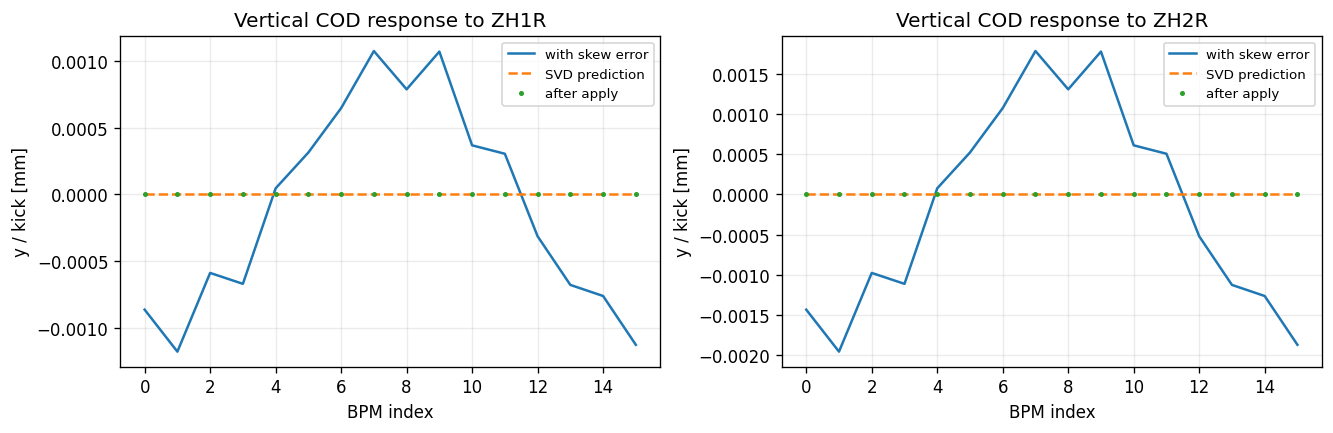

In [6]:
lattice_skew = rft.Lattice(str(DR_TWISS_FILE))
skew_correction = ATFDRRingCorrection(lattice_skew)
skew_names = skew_correction.get_skew_corrector_names()[:8]
skew_bpm_names = skew_correction.bpm_names[:16]

started = time.monotonic()
coupling_response = skew_correction.compute_coupling_response(
    probe_corrector_names=("ZH1R", "ZH2R"),
    skew_corrector_names=skew_names,
    bpm_names=skew_bpm_names,
    probe_perturbation=1e-4,
    skew_perturbation=1e-5,
)
response_seconds = time.monotonic() - started
print(f"coupling response shape: {coupling_response.matrix.shape} (rows, skew actuators)")
print(f"response calculation time: {response_seconds:.1f} s")

injected_skew = skew_names[0]
skew_correction.set_skew_strength(injected_skew, 1e-3)
skew_suggestion = skew_correction.propose_coupling_correction(
    coupling_response,
    max_skew_correctors=6,
)
coupling_signal_after = skew_correction.apply_coupling_correction(skew_suggestion)
coupling_rms_after = rms(coupling_signal_after)

print(
    f"Injected {injected_skew}=1e-3 K1L; coupling RMS "
    f"{skew_suggestion.rms_before:.3e} -> {coupling_rms_after:.3e} mm/kick"
)
print(f"selected skew actuators: {skew_suggestion.selected_skew_correctors}")

before_by_probe = skew_suggestion.measured_signal.reshape(2, len(skew_bpm_names))
predicted_by_probe = skew_suggestion.predicted_signal.reshape(2, len(skew_bpm_names))
after_by_probe = coupling_signal_after.reshape(2, len(skew_bpm_names))
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5), sharex=True, constrained_layout=True)
for axis, probe_index, probe_name in zip(axes, range(2), ("ZH1R", "ZH2R")):
    axis.plot(before_by_probe[probe_index], label="with skew error")
    axis.plot(predicted_by_probe[probe_index], "--", label="SVD prediction")
    axis.plot(after_by_probe[probe_index], ".", ms=4, label="after apply")
    axis.set(title=f"Vertical COD response to {probe_name}", xlabel="BPM index", ylabel="y / kick [mm]")
    axis.legend(fontsize=8)
plt.show()

assert len(skew_suggestion.selected_skew_correctors) <= 6
assert skew_suggestion.rms_predicted < 0.01 * skew_suggestion.rms_before
assert coupling_rms_after < 0.001 * skew_suggestion.rms_before

## 6. Summary

Passing assertions verifies response-based correction in this RF-Track model. SAD output is still required for an absolute SAD/RF-Track optics comparison.

In [7]:
summary_rows = [
    ("COD x", cod_results["x"]["rms_before"], cod_results["x"]["rms_after"], "mm"),
    ("COD y", cod_results["y"]["rms_before"], cod_results["y"]["rms_after"], "mm"),
    ("dispersion Dx-target", dispersion_suggestion.dispersion_rms_before,
     dispersion_error_after, "mm/delta"),
    ("skew coupling signal", skew_suggestion.rms_before, coupling_rms_after, "mm/kick"),
]
print(f"{'test':<24} {'before RMS':>14} {'after RMS':>14}  unit")
print("-" * 64)
for name, before, after, unit in summary_rows:
    print(f"{name:<24} {before:14.4e} {after:14.4e}  {unit}")
print("\nAll correction checks passed.")

test                         before RMS      after RMS  unit
----------------------------------------------------------------
COD x                        1.8690e-03     8.9968e-05  mm
COD y                        4.0902e-04     4.3198e-05  mm
dispersion Dx-target         2.6127e+00     7.5331e-03  mm/delta
skew coupling signal         1.0306e-03     1.2107e-08  mm/kick

All correction checks passed.
